### 4. Connect all airports in a State (California) with Carrier Delay as weights using Minimum Spanning Tree (Kruskal's)

In [14]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
# Loading the dataset
flights = pd.read_csv('August_2018_Nationwide.csv')

In [16]:
# ============================================================
# STEP 1: SELECT AIRPORTS (SUBGRAPH CREATION)
# ============================================================

# We focus on airports within California
# WHY?
# → Reduces problem size
# → Makes analysis region-specific (real-world use case)

airport_codes = ['BUR', 'LGB', 'LAX', 'OAK', 'ONT', 'SMF', 'SAN', 'SFO', 'SJC', 'SNA']


In [20]:
# ============================================================
# STEP 2: FILTER DATA
# ============================================================

# Keep only flights where BOTH origin and destination are in selected airports

filtered_df = flights[
    flights['ORIGIN'].isin(airport_codes) &
    flights['DEST'].isin(airport_codes)
]

# Replace missing values with 0
# WHY?
# → Missing delay treated as no delay
filtered_df.fillna(0)

# Keep only flights where carrier delay > 0
# WHY?
# → We are focusing on delay-based optimization
# → Zero-delay edges are not useful for minimizing delay

filtered_df = filtered_df[filtered_df['CARRIER_DELAY'] > 0]

#### Kruskal's algorithm to identify the best method to connect all California airports with Carrier Delay as weights

In [21]:
# ============================================================
# STEP 3: GRAPH CREATION
# ============================================================

# Create an UNDIRECTED graph
# WHY UNDIRECTED?
# → For connectivity, direction doesn't matter
# → We only care about connecting airports

G_filtered = nx.Graph()

# Add edges (airport connections)
for index, row in filtered_df.iterrows():

    # Each edge represents connection between airports
    # Weight = carrier delay

    G_filtered.add_edge(
        row['ORIGIN'],
        row['DEST'],
        weight=abs(row['CARRIER_DELAY'])
    )

# RESULT:
# Nodes = Airports
# Edges = Connections
# Weight = Delay

In [22]:
# ============================================================
# STEP 4: MINIMUM SPANNING TREE (KRUSKAL)
# ============================================================

# WHAT IS MST?
# → Connect all nodes with minimum total weight (delay)

# WHY KRUSKAL?
# → Greedy algorithm
# → Efficient for sparse graphs
# → Easy to implement

mst_filtered = nx.minimum_spanning_tree(
    G_filtered,
    algorithm='kruskal'
)


In [23]:
# ============================================================
# STEP 5: TOTAL DELAY CALCULATION
# ============================================================

# Full network delay
total_delay_full = sum(
    weight for (u, v, weight) in G_filtered.edges(data='weight')
)

# MST delay
total_delay_mst = sum(
    weight for (u, v, weight) in mst_filtered.edges(data='weight')
)

# WHY THIS COMPARISON?
# → Shows how much delay is reduced by optimization

print("Full Network Delay:", total_delay_full)
print("MST Delay:", total_delay_mst)

Full Network Delay: 562.0
MST Delay: 36.0


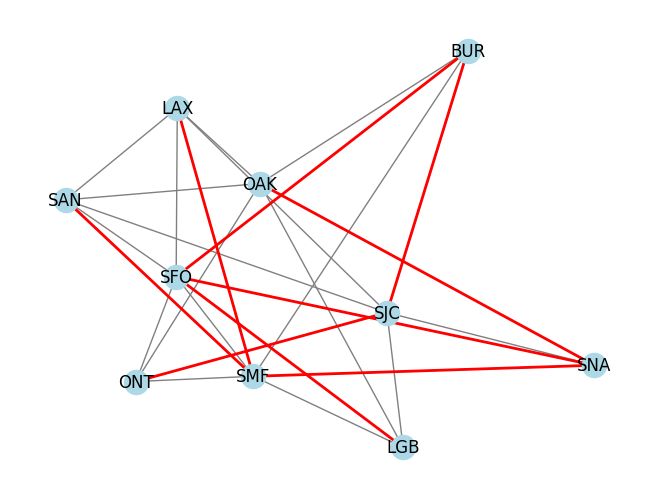

In [25]:
# ============================================================
# STEP 6: VISUALIZATION
# ============================================================

# Layout for graph visualization
pos = nx.spring_layout(G_filtered)

# Draw full graph (all connections)
nx.draw(
    G_filtered,
    pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray'
)

# Highlight MST edges
nx.draw_networkx_edges(
    mst_filtered,
    pos,
    edge_color='red',
    width=2
)

plt.show()

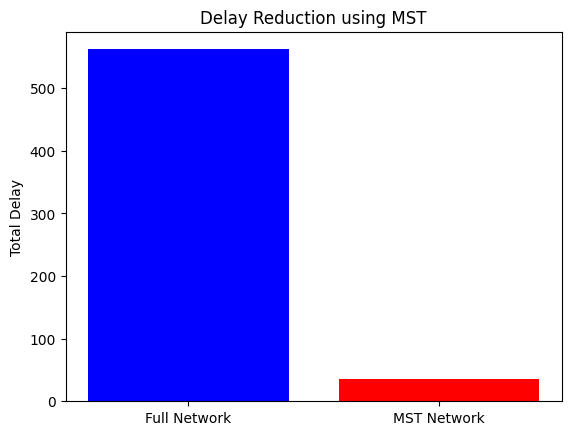

In [27]:
# ============================================================
# STEP 7: BAR CHART COMPARISON
# ============================================================

# Compare delays visually

delays = [total_delay_full, total_delay_mst]
labels = ['Full Network', 'MST Network']

plt.bar(labels, delays, color=['blue', 'red'])
plt.ylabel('Total Delay')
plt.title('Delay Reduction using MST')

plt.show()

 **Grey lines:** Current connections between airports (California)
 
 **Red lines:** Suggested connections between airports (California) using Kruskal's

**Building the Filtered Graph:**
1. A new graph G_filtered is initialized.
2. The script iterates through filtered_df, which is presumably a pandas DataFrame containing filtered flight data with columns 'ORIGIN', 'DEST', and 'CARRIER_DELAY'.
3. For each row in filtered_df, an edge is added between the origin and destination airports with a weight equal to the absolute value of the carrier delay (abs(row['CARRIER_DELAY'])). This ensures that delay values are positive, which is typical for weights in graph algorithms.

**Computing the Minimum Spanning Tree (MST):**
1. The Minimum Spanning Tree (MST) of G_filtered is computed using Kruskal's algorithm. Kruskal's algorithm is a greedy algorithm that finds the minimum spanning tree for a connected weighted graph, ensuring that the tree includes every vertex with the minimal possible total edge weight.

**Calculating Total Delays:**
1. total_delay_full: Calculates the total delay in the full network by summing the weights of all edges in G_filtered.
2. total_delay_mst: Calculates the total delay in the MST by summing the weights of all edges in the MST (mst_filtered).

**Outputting Total Delays:**
1. Prints the total delays for the full network and the MST, providing a comparison to see how much delay is reduced when using the MST instead of the full network.

**Plotting the Graph and MST:**
Uses nx.spring_layout(G_filtered) to generate positions for all nodes in a visually appealing way.
Plots G_filtered using a standard visualization with labels and node colors.
Overlays the MST on the same plot with edges colored red to distinguish them from the full network's edges.

**Plotting Delay Comparison:**
Creates a bar chart comparing the total delays of the full network and the MST. This visual comparison helps to illustrate the effectiveness of the MST in minimizing the total delay across the network.

**Significant Reduction in Total Delay:** The total delay in the full network is 562 units, while in the MST it is significantly reduced to only 36 units. This shows a drastic reduction in total delay when the network is optimized to only include the most necessary connections, as represented by the MST.

**Efficiency of MST:** The MST effectively minimizes the cumulative weight (in this case, delay) of the edges included in the tree. This optimization demonstrates the strength of using MST in network analysis, particularly in contexts where it's critical to minimize a certain cost (like time or resource expenditure).

**Implications for Network Planning:** In practical terms, especially in transportation and logistics (like airline routing), constructing networks according to principles similar to those of MST can lead to significant efficiency gains. By only maintaining essential routes that offer the most direct and least delayed connections, airlines could potentially reduce operational delays and improve overall service quality.

**Visualization and Decision Making:** The visual representation provided by the network graph and the bar chart offers clear insights into how network optimization affects performance metrics like delays. This can be extremely useful for decision-makers in planning and optimizing operational networks.